# GESTION DE NULOS

In [1]:
#Tratamiento de datos
import pandas as pd

import sys
sys.path.append('../')
from SRC import sp_nulos as sn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer #instalar antes de importar ver en google pypi sklearn
from sklearn.impute import KNNImputer, IterativeImputer

In [2]:
df_n = pd.read_csv('../Datos/df_data_limpios.csv')
df= df_n.copy()

Vista preliminar de nulos en el df

In [3]:
df.isnull().mean()*100

age                  11.906977
job                   0.802326
marital               0.197674
education             4.202326
default              20.886047
housing               2.386047
loan                  2.386047
contact               0.000000
duration              0.000000
campaign              0.000000
pdays                 0.000000
previous              0.000000
poutcome              0.000000
emp_var_rate          0.000000
cons_price_idx        1.095349
cons_conf_idx         0.000000
euribor3m            21.525581
nr_employed           0.000000
subscription_prod     0.000000
date_contact          0.576744
latitude              0.000000
longitude             0.000000
income                0.000000
kidhome               0.000000
teenhome              0.000000
dt_customer          60.774419
numwebvisitsmonth     0.000000
id                    0.000000
default_str          20.886047
housing_str           2.386047
loan_str              2.386047
dtype: float64

In [4]:
df_nulos = df.loc[:,df.isnull().sum()>0]
df_nulos

,age,job,marital,education,default,housing,loan,cons_price_idx,euribor3m,date_contact,dt_customer,default_str,housing_str,loan_str
0,NaN,housemaid,married,basic_4y,0.0,0.0,0.0,93.994,4.857,2019-08-02,2012-04-04,no,no,no
1,57.0,services,married,high_school,NaN,0.0,0.0,93.994,NaN,2016-09-14,NaN,NaN,no,no
2,37.0,services,married,high_school,0.0,1.0,0.0,93.994,4.857,2019-02-15,2012-02-02,no,yes,no
3,40.0,admin,married,basic_6y,0.0,0.0,0.0,93.994,NaN,2015-11-29,NaN,no,no,no
4,56.0,services,married,high_school,0.0,0.0,1.0,93.994,NaN,2017-01-29,NaN,no,no,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42995,NaN,admin,married,university_degree,0.0,0.0,0.0,93.444,NaN,2015-10-13,2014-08-03,no,no,no
42996,34.0,technician,married,professional_course,0.0,1.0,1.0,93.200,NaN,2018-03-17,2014-11-03,no,yes,yes
42997,NaN,blue_collar,single,basic_6y,0.0,1.0,0.0,93.918,NaN,2016-09-15,NaN,no,yes,no
42998,NaN,admin,married,university_degree,NaN,0.0,0.0,93.918,4.958,2019-09-23,NaN,NaN,no,no


# GESTION DE NULOS, COLUMNAS CATEGORICAS

1) Comprobación de si alguna categoría sobresale sobre el resto

In [5]:
sn.estadist_col_cat(df_nulos)

JOB
job
admin            25.286047
blue_collar      22.451163
technician       16.339535
services          9.679070
management        7.093023
retired           4.162791
entrepreneur      3.539535
self_employed     3.462791
housemaid         2.611628
unemployed        2.472093
student           2.100000
Name: count, dtype: float64
------------------------
MARITAL
marital
married     60.462791
single      28.151163
divorced    11.188372
Name: count, dtype: float64
------------------------
EDUCATION
education
university_degree      29.586047
high_school            23.081395
basic_9y               14.672093
professional_course    12.737209
basic_4y               10.130233
basic_6y                5.548837
illiterate              0.041860
Name: count, dtype: float64
------------------------
DATE_CONTACT
date_contact
2018-02-28    0.220930
2016-02-28    0.218605
2015-02-28    0.213953
2017-02-28    0.206977
2019-02-28    0.197674
                ...   
2018-12-17    0.025581
2019-12-21    0.

## VISUALIZACION

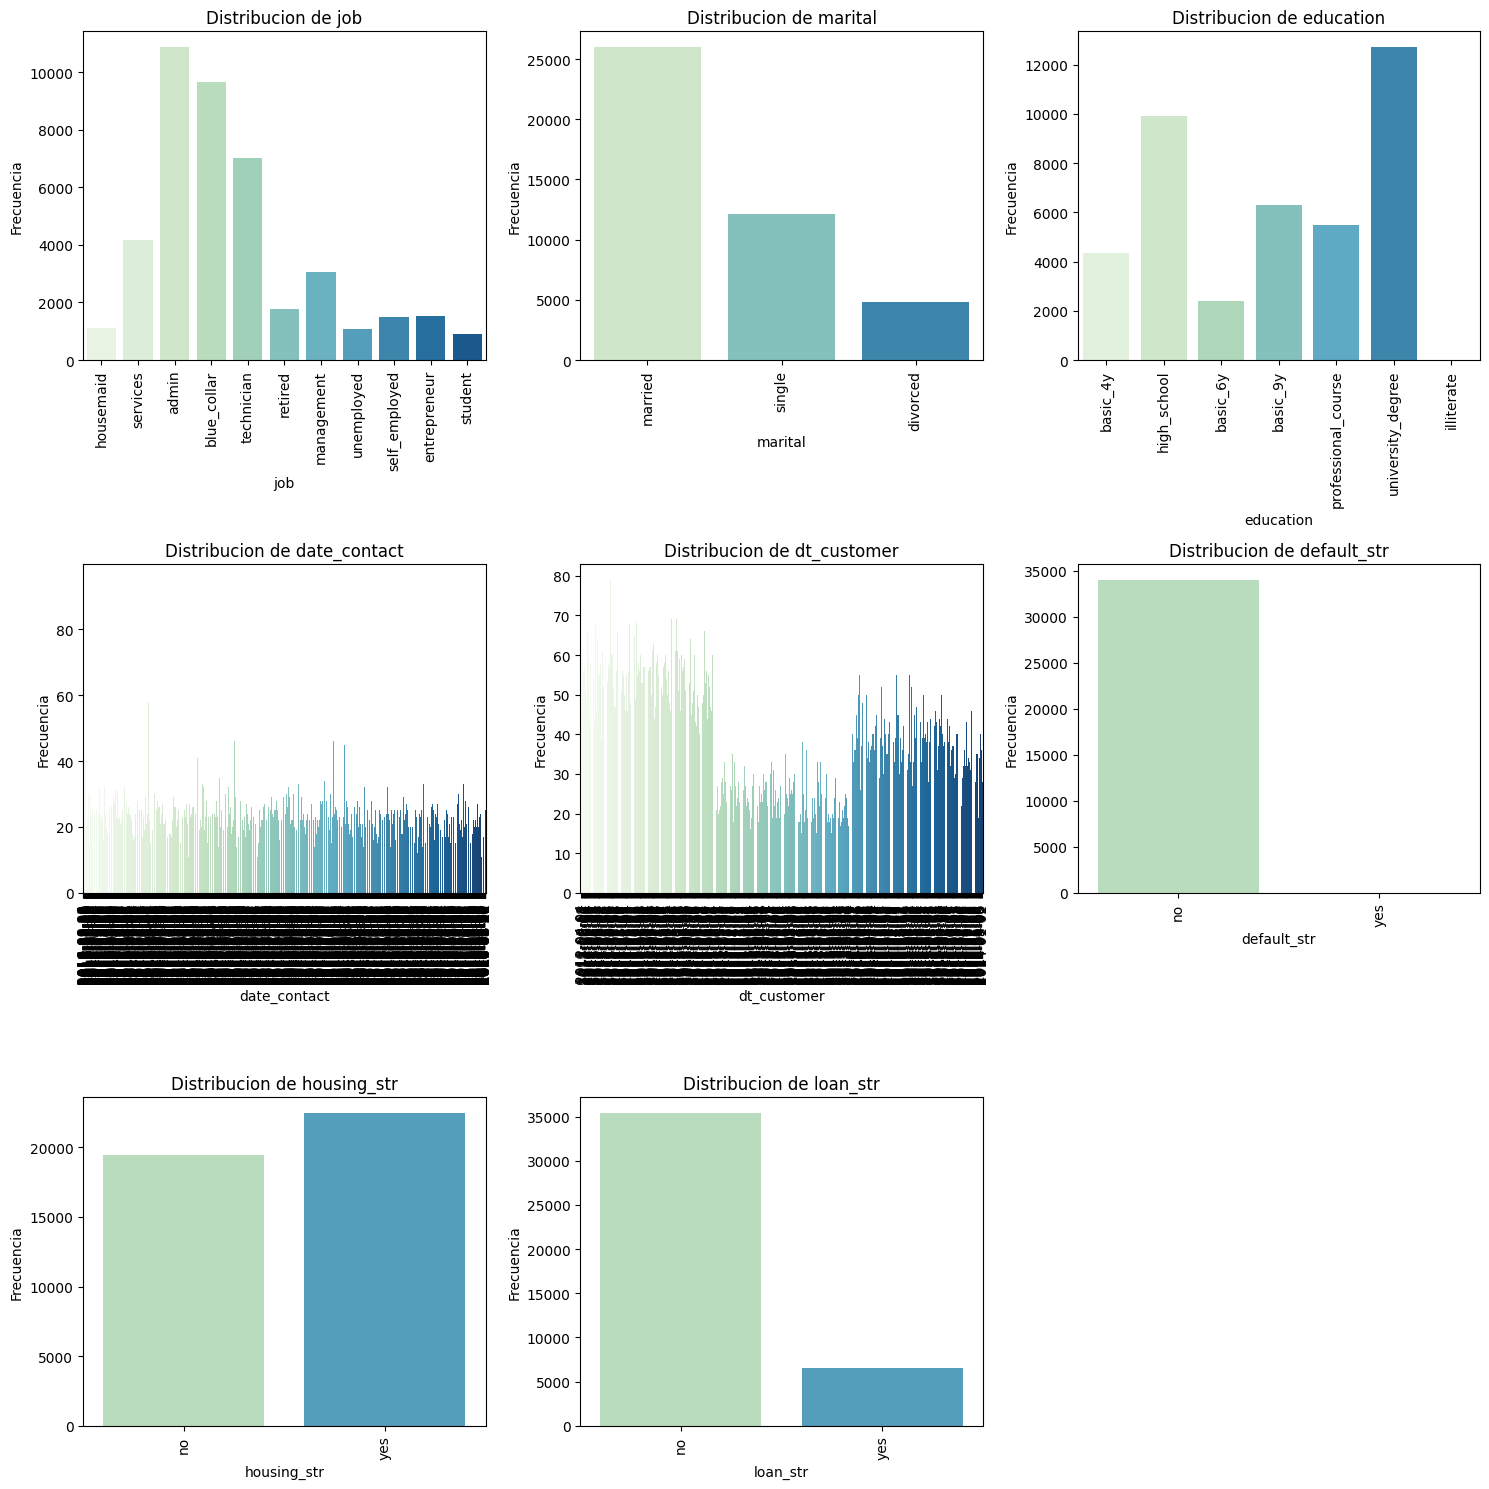

In [6]:
sn.subplot_col_cat(df_nulos)

In [7]:
df_nulos.select_dtypes(include='O').isnull().mean()*100

job              0.802326
marital          0.197674
education        4.202326
date_contact     0.576744
dt_customer     60.774419
default_str     20.886047
housing_str      2.386047
loan_str         2.386047
dtype: float64

- job: 0.80% nulos, son pocos pero ninguna categoria destaca (moda descartada) imputaremos unknown
- marital: married destaca sobre las demas categorias y hay pocos nulos 0.19% (moda razonable) imputaremos "married" 
- education: gran porcentaje de nulos 4.20%  Imputaremos "unknown"
- default: destaca el "no" 79.10 % pero elevado numero de nulos 20.88% (moda descartada)Imputaremos "unknown"
- housing_str: no destaca ninguno y 2.38% de nulos (moda descartada) Imputaremos "unknown"
- Loan_str: destaca el "no" (82.42%) y n. de nulos 2.38% (posible moda) Imputaremos "no"

### IMPUTACION NULOS CATEGORICAS

In [8]:
# Imputacion con la moda
df['marital'] = df['marital'].fillna(df['marital'].mode()[0])
df['loan_str'] = df['loan_str'].fillna(df['loan_str'].mode()[0])

# Imputacion con "unknown"
cols_unknown = ['job', 'education', 'default_str', 'housing_str']
for col in cols_unknown:
    df[col] = df[col].fillna('unknown')

In [9]:
df.isnull().mean()*100

age                  11.906977
job                   0.000000
marital               0.000000
education             0.000000
default              20.886047
housing               2.386047
loan                  2.386047
contact               0.000000
duration              0.000000
campaign              0.000000
pdays                 0.000000
previous              0.000000
poutcome              0.000000
emp_var_rate          0.000000
cons_price_idx        1.095349
cons_conf_idx         0.000000
euribor3m            21.525581
nr_employed           0.000000
subscription_prod     0.000000
date_contact          0.576744
latitude              0.000000
longitude             0.000000
income                0.000000
kidhome               0.000000
teenhome              0.000000
dt_customer          60.774419
numwebvisitsmonth     0.000000
id                    0.000000
default_str           0.000000
housing_str           0.000000
loan_str              0.000000
dtype: float64

## OUTLIERS

### VISUALIZACION DE OUTLIERS

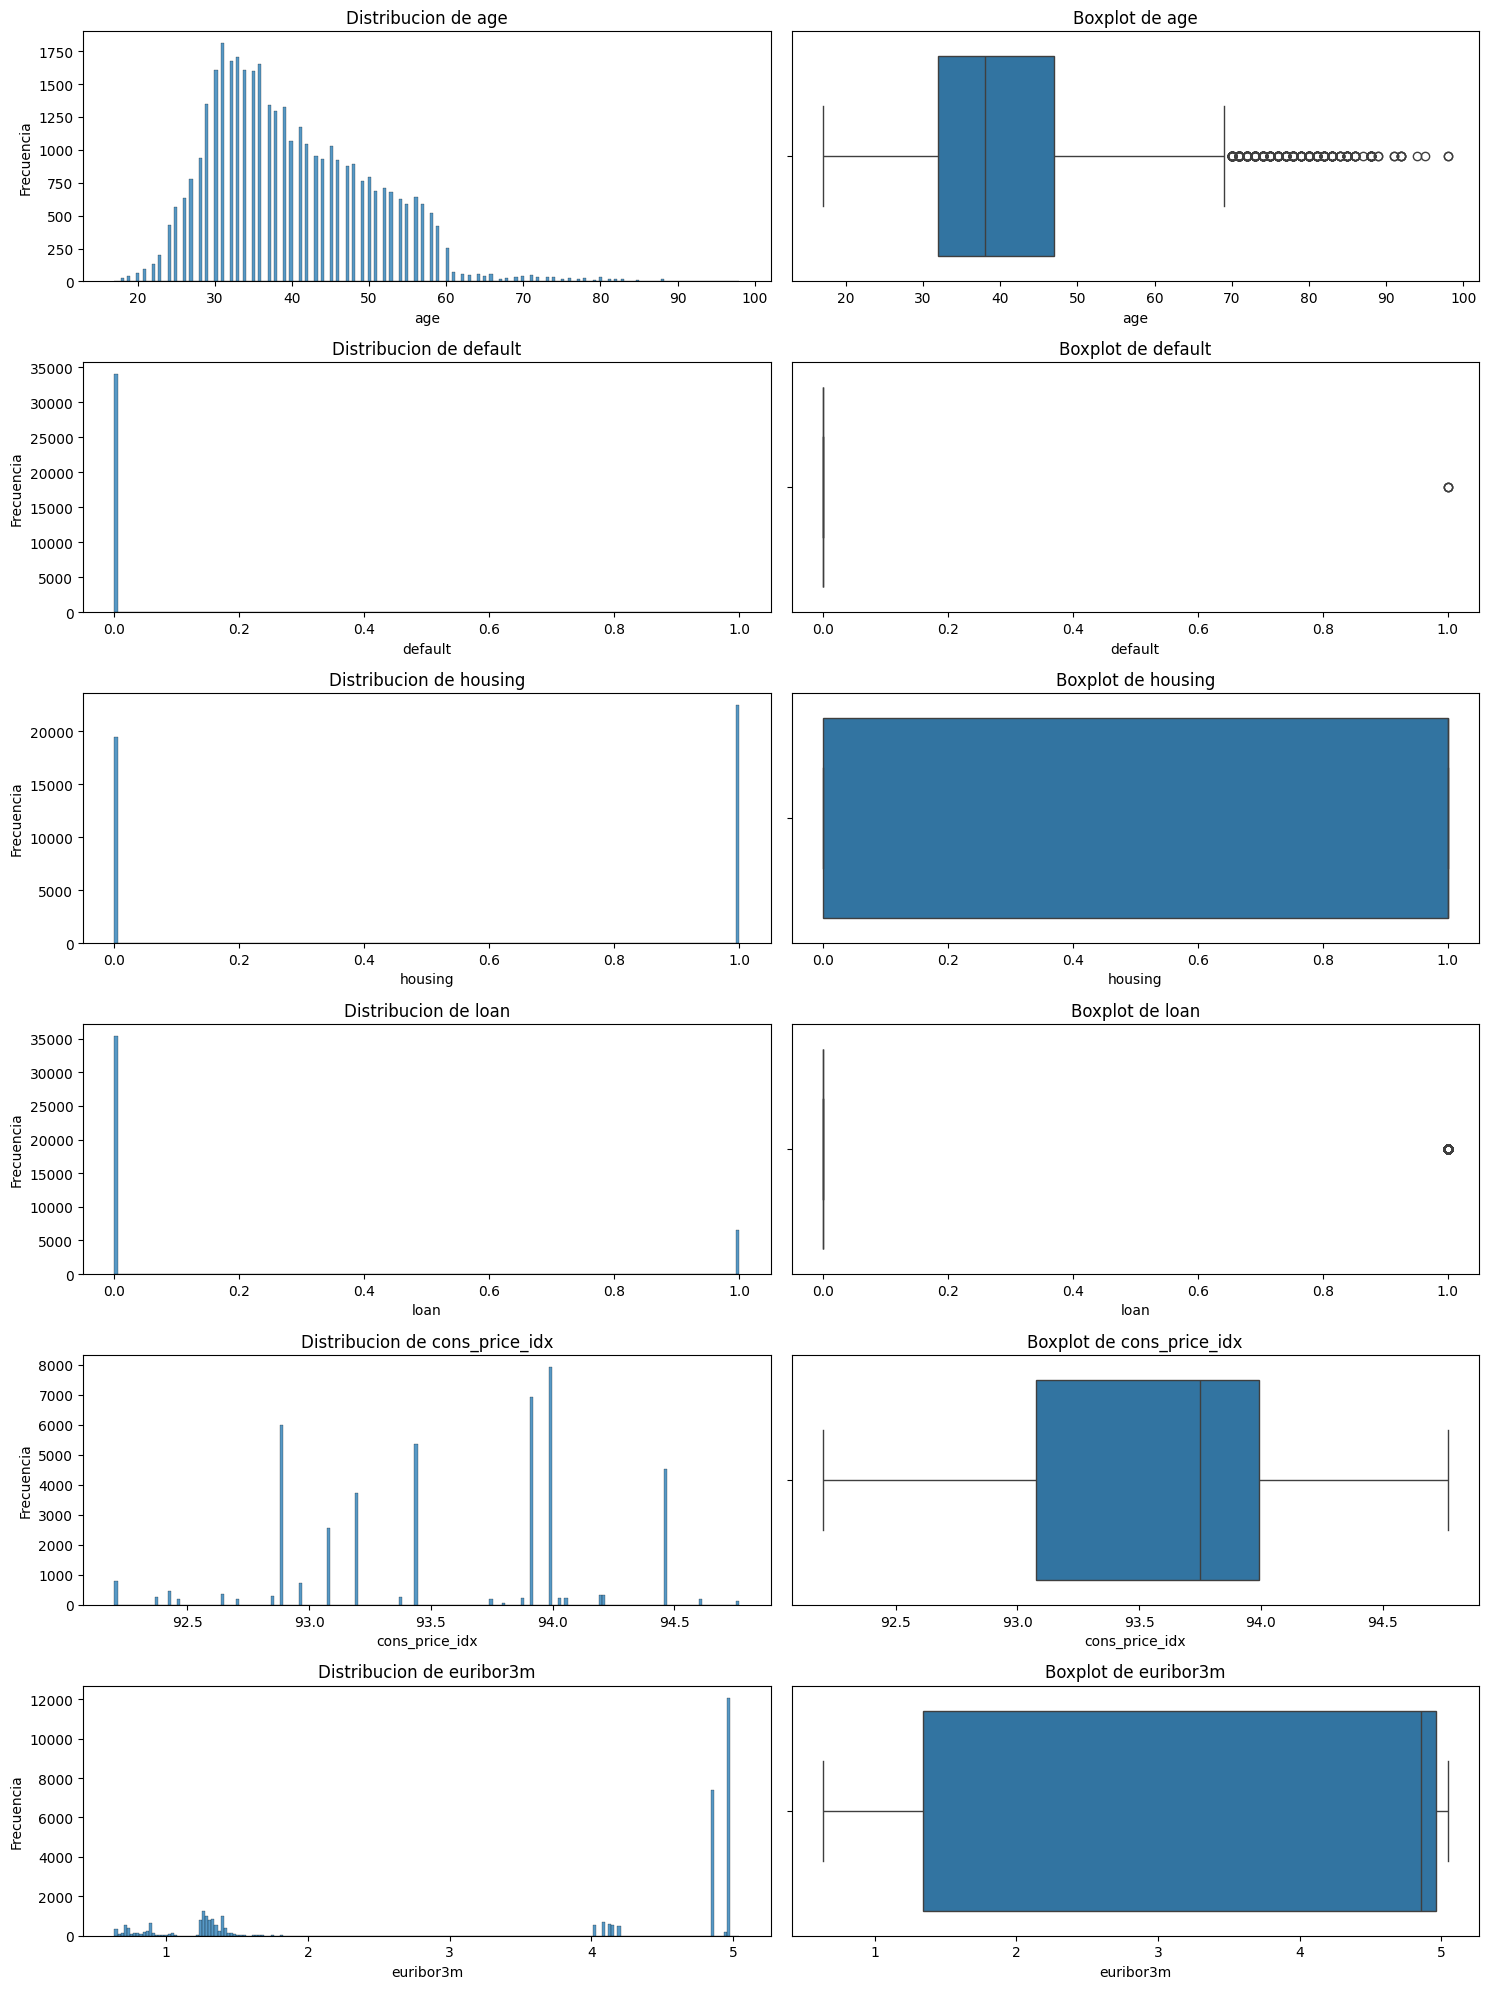

In [10]:
sn.subplot_col_num(df_nulos)

### CALCULO DE OUTLIERS

In [11]:
sn.calculo_outliers(df,['age','cons_price_idx','euribor3m'])

En la columna AGE tenenemos un total de 441 outliers, lo que representa un 1.0255813953488373% del total
En la columna CONS_PRICE_IDX tenenemos un total de 0 outliers, lo que representa un 0.0% del total
En la columna EURIBOR3M tenenemos un total de 0 outliers, lo que representa un 0.0% del total


In [12]:
df_nulos.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'cons_price_idx', 'euribor3m', 'date_contact', 'dt_customer',
       'default_str', 'housing_str', 'loan_str'],
      dtype='object')

In [13]:
df.isnull().mean()*100

age                  11.906977
job                   0.000000
marital               0.000000
education             0.000000
default              20.886047
housing               2.386047
loan                  2.386047
contact               0.000000
duration              0.000000
campaign              0.000000
pdays                 0.000000
previous              0.000000
poutcome              0.000000
emp_var_rate          0.000000
cons_price_idx        1.095349
cons_conf_idx         0.000000
euribor3m            21.525581
nr_employed           0.000000
subscription_prod     0.000000
date_contact          0.576744
latitude              0.000000
longitude             0.000000
income                0.000000
kidhome               0.000000
teenhome              0.000000
dt_customer          60.774419
numwebvisitsmonth     0.000000
id                    0.000000
default_str           0.000000
housing_str           0.000000
loan_str              0.000000
dtype: float64

En la columna "age" se han identificado algunos valores atípicos correspondientes a edades entre 70 y 100 años, lo que representa aproximadamente un 1% del total de los datos. A pesar de que es un % bajo de outliers, dado que estos valores reflejan casos reales y no errores, no se eliminarán para evitar sesgar el análisis.

# GESTION DE NULOS, COLUMNAS NUMERICAS

In [14]:
df_nulos.select_dtypes(include='number').isnull().mean()*100

age               11.906977
default           20.886047
housing            2.386047
loan               2.386047
cons_price_idx     1.095349
euribor3m         21.525581
dtype: float64

- Default, housing y loan las dejamos de lado, porque ya hemos visto sus versiones categoricas default_str, housing_str y loan_str
- Asi que nos centraremos en las columnas "age", "cons_price_idx" y "euribor3m"
- En el caso de "cons_price_idx" y "euribor3m", no hay outliers asi que sustituiremos por la media o mediana.

In [15]:
df_nulos.describe().T

,count,mean,std,min,25%,50%,75%,max
age,37880.0,39.977112,10.437957,17.000,32.000,38.000,47.000,98.000
default,34019.0,0.000088,0.009390,0.000,0.000,0.000,0.000,1.000
housing,41974.0,0.535998,0.498708,0.000,0.000,1.000,1.000,1.000
loan,41974.0,0.155620,0.362499,0.000,0.000,0.000,0.000,1.000
cons_price_idx,42529.0,93.574219,0.579548,92.201,93.075,93.749,93.994,94.767
euribor3m,33744.0,3.616521,1.737117,0.634,1.344,4.857,4.961,5.045


En el caso de "euribor3m"  la media está notablemente más baja que la mediana, eso confirma la asimetría (cola hacia valores bajos). Escogere la mediana porque es robusta frente a valores atípicos y a distribuciones no normales.

En el caso de "cons_price_idx" media y mediana son practicamente iguales estando de nuevo la media ligeramente a la izquierda escogeremos de nuevo la mediana para imputar los valores nulos

En el caso de "age" como tiene outliers no lo sustituiremos por la media o mediana. Habra que usar estadisticos avanzados. 

## RELLENO DE NULOS EN NUMERICAS

In [16]:
df_filled_simple = df.fillna({'euribor3m':df['euribor3m'].median(),'cons_price_idx':df['cons_price_idx'].median()})

In [17]:
df_filled_simple.isnull().sum()

age                   5120
job                      0
marital                  0
education                0
default               8981
housing               1026
loan                  1026
contact                  0
duration                 0
campaign                 0
pdays                    0
previous                 0
poutcome                 0
emp_var_rate             0
cons_price_idx           0
cons_conf_idx            0
euribor3m                0
nr_employed              0
subscription_prod        0
date_contact           248
latitude                 0
longitude                0
income                   0
kidhome                  0
teenhome                 0
dt_customer          26133
numwebvisitsmonth        0
id                       0
default_str              0
housing_str              0
loan_str                 0
dtype: int64

### ESTADISTICOS AVANZADOS

In [18]:
df_filled_simple = sn.imputar_knn(df_filled_simple,['age'])

In [19]:
df_filled_simple = sn.imputar_iterative(df_filled_simple,['age'])

,count,mean,std,min,25%,50%,75%,max
age_iterative,43000.0,39.977112,9.79683,17.0,33.0,39.977112,46.0,98.0


In [20]:
df_filled_simple[['age','age_iterative', 'age_knn']].describe().T

,count,mean,std,min,25%,50%,75%,max
age,37880.0,39.977112,10.437957,17.0,32.0,38.000000,47.0,98.0
age_iterative,43000.0,39.977112,9.796830,17.0,33.0,39.977112,46.0,98.0
age_knn,43000.0,39.977112,9.796830,17.0,33.0,39.977112,46.0,98.0


Escogeremos el metodo que tenga los estadisticos lo mas parecidos a 'age' en este caso podemos escoger cualquiera de las dos, asi que procedemos a eliminar una de las dos y la original

In [21]:
df_filled_simple.drop(columns=['age', 'age_iterative'], inplace=True)

In [22]:
df_filled_simple.isnull().sum()

job                      0
marital                  0
education                0
default               8981
housing               1026
loan                  1026
contact                  0
duration                 0
campaign                 0
pdays                    0
previous                 0
poutcome                 0
emp_var_rate             0
cons_price_idx           0
cons_conf_idx            0
euribor3m                0
nr_employed              0
subscription_prod        0
date_contact           248
latitude                 0
longitude                0
income                   0
kidhome                  0
teenhome                 0
dt_customer          26133
numwebvisitsmonth        0
id                       0
default_str              0
housing_str              0
loan_str                 0
age_knn                  0
dtype: int64